# Collect Results for Paper Figures

This notebook is a paper-facing analysis notebook for the Sachs benchmark slice.

It assumes the following files already exist under `experiments/responses/sachs/`:
- `sachs_summary.csv`
- `sachs_all_systems.csv`
- `sachs_main_cohort.csv`

The notebook focuses on five analysis blocks:
1. the clean paper cohort,
2. classical-vs-LLM comparison,
3. prompt-representation sensitivity,
4. semantic-prior audit,
5. a separate Qwen/GRPO comparison on shared Sachs settings.

The main paper analysis uses `avg_*` metrics rather than consensus metrics.
All figures are saved under `experiments/responses/sachs/paper_figures/`.


In [117]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

REPO_ROOT = Path.cwd().parent
if REPO_ROOT.name == 'experiments' and not (REPO_ROOT / 'responses').exists():
    REPO_ROOT = REPO_ROOT.parent
elif not (REPO_ROOT / 'experiments').exists() and (REPO_ROOT.parent / 'experiments').exists():
    REPO_ROOT = REPO_ROOT.parent

GRAPH_NAME = 'sachs'
RESPONSES_DIR = REPO_ROOT / 'experiments' / 'responses_before' / GRAPH_NAME
RAW_SUMMARY_CSV = RESPONSES_DIR / 'sachs_summary.csv'
ALL_SYSTEMS_CSV = RESPONSES_DIR / 'sachs_all_systems.csv'
MAIN_COHORT_CSV = RESPONSES_DIR / 'sachs_main_cohort.csv'
FIG_DIR = RESPONSES_DIR / 'paper_figures'
TABLE_DIR = RESPONSES_DIR / 'paper_tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
PALETTE = {
    'summary_joint': '#1f77b4',
    'matrix': '#ff7f0e',
    'names_only': '#2ca02c',
    'ENCO': '#d62728',
    'PC': '#9467bd',
    'GES': '#8c564b',
}


In [118]:
REPO_ROOT = Path.cwd().parent
REPO_ROOT

PosixPath('/Users/yuenc2/Desktop/ENCO')

In [119]:
raw_summary = pd.read_csv(RAW_SUMMARY_CSV)
all_systems = pd.read_csv(ALL_SYSTEMS_CSV)
main = pd.read_csv(MAIN_COHORT_CSV)

print('Raw summary:', raw_summary.shape)
print('All systems:', all_systems.shape)
print('Main cohort:', main.shape)

display(main.sort_values(['obs_n', 'int_n', 'system_kind', 'system', 'prompt_style', 'naming_regime']).reset_index(drop=True))


Raw summary: (598, 109)
All systems: (105, 18)
Main cohort: (36, 18)


,dataset,system,system_kind,model,prompt_style,naming_regime,obs_n,int_n,consensus_f1,consensus_shd,consensus_precision,consensus_recall,consensus_accuracy,avg_f1,avg_shd,valid_rows,num_rows,source_file
0,sachs,gpt-5-mini,llm,gpt-5-mini,names_only,names_only,0,0,0.500000,14.0,0.636364,0.411765,0.872727,0.496322,14.6,5,5,responses_names_only_p5_gpt-5-mini.csv
1,sachs,ENCO,classical,ENCO,classical,real,0,50,0.102564,35.0,0.090909,0.117647,0.681818,0.102564,35.0,1,1,predictions_obs0_int50_ENCO.csv
2,sachs,ENCO,classical,ENCO,classical,real,0,100,0.136364,38.0,0.111111,0.176471,0.654545,0.136364,38.0,1,1,predictions_obs0_int100_ENCO.csv
3,sachs,gpt-5-mini,llm,gpt-5-mini,matrix,anonymized,0,100,0.190476,17.0,0.500000,0.117647,0.845455,0.257781,20.8,5,5,responses_obs0_int100_shuf1_p5_anon_matrix_gpt...
4,sachs,gpt-5-mini,llm,gpt-5-mini,matrix,real,0,100,0.320000,17.0,0.500000,0.235294,0.845455,0.424849,16.2,5,5,responses_obs0_int100_shuf1_p5_matrix_gpt-5-mi...
5,sachs,gpt-5-mini,llm,gpt-5-mini,summary,anonymized,0,100,NaN,17.0,NaN,0.000000,0.845455,0.356080,53.8,5,5,responses_obs0_int100_shuf1_p5_anon_summary_gp...
6,sachs,gpt-5-mini,llm,gpt-5-mini,summary,real,0,100,0.424242,19.0,0.437500,0.411765,0.827273,0.431748,22.6,5,5,responses_obs0_int100_shuf1_p5_summary_gpt-5-m...
7,sachs,ENCO,classical,ENCO,classical,real,0,200,0.133333,39.0,0.107143,0.176471,0.645455,0.133333,39.0,1,1,predictions_obs0_int200_ENCO.csv
8,sachs,gpt-5-mini,llm,gpt-5-mini,matrix,anonymized,0,200,0.095238,19.0,0.250000,0.058824,0.827273,0.296713,19.2,5,5,responses_obs0_int200_shuf1_p5_anon_matrix_gpt...
9,sachs,gpt-5-mini,llm,gpt-5-mini,matrix,real,0,200,0.250000,18.0,0.428571,0.176471,0.836364,0.415344,16.4,5,5,responses_obs0_int200_shuf1_p5_matrix_gpt-5-mi...


In [120]:
raw_summary['model'].unique()

array(['colRandom_gpt-5-mini', 'colReverse_gpt-5-mini',
       'colReverse_topo_gpt-5-mini', 'colTopo_gpt-5-mini', 'gpt-5-mini',
       'gpt-5.2-pro', 'Meta-Llama-3-8B', 'Qwen3-4B-Thinking-2507',
       'Qwen3.5-9B', 'checkpoint-100', 'checkpoint-4',
       'cothint_Meta-Llama-3-8B', 'cothint_Qwen3.5-9B',
       'cothint_checkpoint-100', 'cothint_qwen3_4b_cd_format_v4',
       'grpo_sachs_mix_onthefly_mp2', 'grpo_sft_8192',
       'grpo_sft_8192_cd_focus', 'grpo_sft_8192_from4096',
       'respthink_answer_qwen3_4b_cd_format_v5',
       'respthink_answer_wrapchat_qwen3_4b_cd_format_v5', 'sft',
       'stage_3_obs100_int0_bootstrap',
       'stage_3_obs100_int0_graph_scaled', 'stage_3_obs100_int0_retuned',
       'shuf1_gpt-5-mini', 'Qwen3-8B', 'checkpoint-300',
       'grpo_v2_cancer_eq', 'checkpoint-400', 'checkpoint-350',
       'qwen3_4b_cd_format_v5', 'checkpoint-1100', 'checkpoint-900',
       'qwen3_4b_cd_format_v4', 'staged_sft_v3', 'Qwen2-0.5B-Instruct',
       'unknown', 'gpt-

## Main comparison tables

These tables are the paper-facing views for Sachs. The main analysis uses `avg_f1` and `avg_shd`.


In [121]:
repr_table = (
    main[
        (main['system'] == 'gpt-5-mini')
        & (main['prompt_style'].isin(['summary_joint', 'matrix']))
    ]
    .pivot_table(
        index=['obs_n', 'int_n', 'naming_regime'],
        columns='prompt_style',
        values=['avg_f1', 'avg_shd'],
        aggfunc='first',
    )
    .sort_index()
)

repr_table


avg_f1 avg_shd
prompt_style                 matrix  matrix
obs_n int_n naming_regime                  
0     100   anonymized     0.257781    20.8
            real           0.424849    16.2
      200   anonymized     0.296713    19.2
            real           0.415344    16.4

In [122]:
AUDIT_PROMPT = 'summary'

full_info = main[
    (main['system'] == 'gpt-5-mini')
    & (main['prompt_style'] == AUDIT_PROMPT)
].copy()

names_only = main[
    (main['system'] == 'gpt-5-mini')
    & (main['prompt_style'] == 'names_only')
].copy()

if names_only.empty:
    raise ValueError('No names_only row found in main cohort.')

names_only_row = names_only.iloc[0]
real = full_info[full_info['naming_regime'] == 'real'].copy()
anon = full_info[full_info['naming_regime'] == 'anonymized'].copy()

semantic_audit = real.merge(
    anon,
    on=['obs_n', 'int_n', 'prompt_style', 'system', 'system_kind'],
    suffixes=('_real', '_anon'),
)
semantic_audit['names_only_f1'] = float(names_only_row['avg_f1'])
semantic_audit['names_only_shd'] = float(names_only_row['avg_shd'])
semantic_audit['real_minus_anon_f1'] = semantic_audit['avg_f1_real'] - semantic_audit['avg_f1_anon']
semantic_audit['real_minus_names_only_f1'] = semantic_audit['avg_f1_real'] - semantic_audit['names_only_f1']
semantic_audit['anon_minus_names_only_f1'] = semantic_audit['avg_f1_anon'] - semantic_audit['names_only_f1']
semantic_audit['anon_minus_real_shd'] = semantic_audit['avg_shd_anon'] - semantic_audit['avg_shd_real']
semantic_audit = semantic_audit[[
    'obs_n', 'int_n',
    'avg_f1_real', 'avg_f1_anon', 'names_only_f1',
    'real_minus_anon_f1', 'real_minus_names_only_f1', 'anon_minus_names_only_f1',
    'avg_shd_real', 'avg_shd_anon', 'names_only_shd', 'anon_minus_real_shd'
]].sort_values(['obs_n', 'int_n'])

semantic_audit


,obs_n,int_n,avg_f1_real,avg_f1_anon,names_only_f1,real_minus_anon_f1,real_minus_names_only_f1,anon_minus_names_only_f1,avg_shd_real,avg_shd_anon,names_only_shd,anon_minus_real_shd
0,0,100,0.431748,0.356080,0.496322,0.075668,-0.064573,-0.140241,22.6,53.8,14.6,31.2
1,0,200,0.413266,0.422158,0.496322,-0.008891,-0.083055,-0.074164,25.0,40.0,14.6,15.0


## Main paper figures

The figures below correspond to the main benchmark story:
- representation sensitivity,
- semantic-prior audit,
- classical-vs-LLM budget curves.


In [125]:
import pandas as pd
from pathlib import Path

p = Path("/Users/yuenc2/Desktop/ENCO/experiments/responses_before/sachs/sachs_summary.csv")
df = pd.read_csv(p)

# Optional backup
df.to_csv(p.with_suffix(".csv.bak"), index=False)

df["prompt_style"] = df["prompt_style"].replace({
    "summary": "summary_joint",
    "sumamry_joint": "summary_joint",
})

df.to_csv(p, index=False)

print(df["prompt_style"].value_counts(dropna=False))

prompt_style
summary_joint    343
matrix           146
payload           40
names_only        34
enco              26
payload_topk       8
cases              1
Name: count, dtype: int64


In [126]:
# raw_summary[(raw_summary['model'] == 'checkpoint-300') & (raw_summary['obs_n'] == 5000) & (raw_summary['int_n'] == 200)]
raw_summary[raw_summary['model'] == 'checkpoint-900']

,anonymize,avg_FN,avg_FP,avg_TN,avg_TP,avg_accuracy,avg_accuracy_sd,avg_accuracy_se,avg_f1,avg_f1_sd,avg_f1_se,avg_orientation_FN,avg_orientation_TP,avg_orientation_accuracy,avg_orientation_eval_pairs,avg_precision,avg_precision_sd,avg_precision_se,avg_recall,avg_recall_sd,avg_recall_se,avg_shd,avg_shd_sd,avg_shd_se,brier,brier_skeleton,causal_rules,col_order,consensus_K,consensus_accuracy,consensus_f1,consensus_num_edges,consensus_orient_acc,consensus_precision,consensus_recall,consensus_shd,consensus_tau,context_exceeded_any,context_exceeded_by_error_rows,context_exceeded_by_tokens_rows,context_window,dataset,evaluated,format_ok_rows,format_rate,format_scored_rows,give_steps,given_edge_count,given_edge_frac,given_edges,int_n,is_names_only,model,nhd_ci95_high,nhd_ci95_low,nhd_consensus,nhd_iqr,nhd_mean,nhd_mean_se,nhd_ratio_ci95_high,nhd_ratio_ci95_low,nhd_ratio_consensus,nhd_ratio_iqr,nhd_ratio_mean,nhd_ratio_mean_se,nhd_ratio_sd,nhd_sd,num_pred_edges,num_pred_edges_sd,num_pred_edges_se,num_rows,obs_n,prompt_style,prompt_tokens_max,prompt_tokens_mean,prompt_tokens_missing_rows,prompt_tokens_rows,response_csv,row_order,shuffles_per_graph,spread_n,summary_json,tau,true_num_edges,valid_rows,var_accuracy_ci95_high,var_accuracy_ci95_low,var_accuracy_iqr,var_accuracy_sd,var_f1_ci95_high,var_f1_ci95_low,var_f1_iqr,var_f1_sd,var_num_pred_edges_ci95_high,var_num_pred_edges_ci95_low,var_num_pred_edges_iqr,var_num_pred_edges_sd,var_precision_ci95_high,var_precision_ci95_low,var_precision_iqr,var_precision_sd,var_recall_ci95_high,var_recall_ci95_low,var_recall_iqr,var_recall_sd,var_shd_ci95_high,var_shd_ci95_low,var_shd_iqr,var_shd_sd
393,1,9.6,16.6,76.4,7.4,0.761818,0.028313,0.012662,0.358309,0.070483,0.031521,0.6,7.0,0.931429,7.6,0.308798,0.056834,0.025417,0.435294,0.114668,0.051281,26.2,3.114482,1.392839,0.161818,0.308364,0,original,5.0,0.800000,0.266667,13.0,1.0,0.307692,0.235294,22.0,0.7,0,0,0,128000.0,sachs,1,5.0,1.0,5.0,0,0.0,NaN,0.0,200.0,0,checkpoint-900,0.239091,0.193967,0.181818,0.041322,0.216529,0.011511,0.703472,0.579910,0.733333,0.019152,0.641691,0.031521,0.070483,0.025740,24.0,4.527693,2.024846,5,5000.0,summary_joint,97746.0,96993.0,0.0,5.0,/Users/yuenc2/Desktop/ENCO/experiments/respons...,random,1.0,5,/Users/yuenc2/Desktop/ENCO/experiments/respons...,NaN,NaN,5.0,0.786636,0.737000,0.045455,0.028313,0.420090,0.296528,0.019152,0.070483,27.968698,20.031302,5.0,4.527693,0.358615,0.258981,0.067227,0.056834,0.535805,0.334783,0.117647,0.114668,28.929964,23.470036,5.0,3.114482
442,0,15.4,15.2,77.8,1.6,0.721818,0.046621,0.020850,0.135293,0.071775,0.032099,2.6,1.2,0.246667,3.8,0.072487,0.080190,0.035862,0.094118,0.106858,0.047788,30.6,5.128353,2.293469,0.212000,0.325091,0,original,5.0,0.790909,NaN,6.0,0.0,0.000000,0.000000,23.0,0.7,0,0,0,128000.0,sachs,1,5.0,1.0,5.0,0,0.0,NaN,0.0,200.0,0,checkpoint-900,0.290043,0.215742,0.190083,0.074380,0.252893,0.018954,0.997552,0.840096,1.000000,0.171429,0.918824,0.040167,0.089817,0.042383,16.8,7.854935,3.512834,5,5000.0,summary_joint,97980.0,97227.0,0.0,5.0,/Users/yuenc2/Desktop/ENCO/experiments/respons...,random,1.0,5,/Users/yuenc2/Desktop/ENCO/experiments/respons...,NaN,NaN,5.0,0.762684,0.680953,0.081818,0.046621,0.216514,0.054072,0.064593,0.071775,23.685154,9.914846,11.0,7.854935,0.142776,0.002197,0.148148,0.080190,0.187783,0.000452,0.176471,0.106858,35.095199,26.104801,9.0,5.128353


In [127]:
# Always reload to avoid plotting stale in-memory data after file updates.
raw_summary = pd.read_csv(RAW_SUMMARY_CSV)

pretty_model = {
    'ENCO': 'ENCO',
    'gpt-5-mini': 'GPT-5-mini',
    'gpt-5.2-pro': 'GPT-5.2-pro',
    'Qwen3-4B-Thinking-2507': 'Qwen3-4B base',
    'checkpoint-100': 'checkpoint-100',
    'qwen3_4b_cd_format_v5': 'Qwen3-4B CD format v5',
    # 'checkpoint-350': 'checkpoint-350',
    # 'staged_sft_v3': 'staged_sft_v3',
    # 'checkpoint-900': 'checkpoint-900',
    # 'checkpoint-1100': 'checkpoint-1100',
    # 'qwen3_4b_cd_format_v4': 'Qwen3-4B CD format v4',
    # 'Meta-Llama-3-8B': 'Meta-Llama-3-8B',
    # 'Qwen3.5-9B': 'Qwen3.5-9B',
    # 'checkpoint-4': 'checkpoint-4',
    # 'sft': 'SFT',
    # 'grpo_v2_cancer_eq': 'GRPO v2 cancer+eq',
    # 'grpo_sachs_mix_onthefly_mp2': 'GRPO mix',
    # 'grpo_sft_8192': 'GRPO SFT-8192',
    # 'grpo_sft_8192_cd_focus': 'GRPO SFT-8192 CD',
    # 'grpo_sft_8192_from4096': 'GRPO from4096',
    # 'stage_3_obs100_int0_bootstrap': 'stage3 bootstrap',
    # 'stage_3_obs100_int0_graph_scaled': 'stage3 graph-scaled',
    # 'stage_3_obs100_int0_retuned': 'stage3 retuned',
}

# Full-information runs
llm_full_info = raw_summary[
    raw_summary["model"].isin([m for m in pretty_model.keys() if m != "ENCO"])
    & (raw_summary["obs_n"].fillna(-1) == 5000)
    & (raw_summary["int_n"].fillna(-1) == 200)
    & (raw_summary["prompt_style"].isin(["summary_joint", "matrix"]))
    & (raw_summary["response_csv"].str.contains("thinktags|respthink", regex=True, na=False))
].copy()

enco_full_info = raw_summary[
    (raw_summary["model"] == "ENCO")
    & (raw_summary["obs_n"].fillna(-1) == 5000)
    & (raw_summary["int_n"].fillna(-1) == 200)
    & (raw_summary["prompt_style"] == "enco")
].copy()

full_info = pd.concat([llm_full_info, enco_full_info], ignore_index=True)

# Name-only control
name_only = raw_summary[
    raw_summary["model"].isin(pretty_model.keys())
    # & (raw_summary["obs_n"].fillna(-1) == 0)
    # & (raw_summary["int_n"].fillna(-1) == 0)
    & (raw_summary["prompt_style"] == "names_only")
    & (raw_summary["response_csv"].str.contains("thinktags|respthink", regex=True, na=False))
    # & (raw_summary["response_csv"].str.contains("cothint", na=False))
].copy()

full_info["display_model"] = full_info["model"].map(pretty_model)
name_only["display_model"] = name_only["model"].map(pretty_model)

full_info = full_info[full_info["display_model"].notna()].copy()
name_only = name_only[name_only["display_model"].notna()].copy()

full_info["setting"] = full_info["prompt_style"].astype(str)
name_only["setting"] = "name only"
# Put ENCO under one bar category instead of separate summary_joint/matrix bars
full_info["setting"] = full_info["prompt_style"].replace({
    "summary_joint": "summary_joint",
    "matrix": "matrix",
    "enco": "ENCO",
})

full_info["display_model"] = pd.Categorical(
    full_info["display_model"],
    categories=list(pretty_model.values()),
    ordered=True,
)
name_only["display_model"] = pd.Categorical(
    name_only["display_model"],
    categories=list(pretty_model.values()),
    ordered=True,
)

plot_real = pd.concat(
    [
        full_info[full_info["anonymize"].fillna(0).astype(int) == 0],
        name_only,
    ],
    ignore_index=True,
)

plot_anon = full_info[
    full_info["anonymize"].fillna(0).astype(int) == 1
].copy()

plot_real["setting"] = pd.Categorical(
plot_real["setting"],
categories=["name only", "summary_joint", "matrix", "ENCO"],
ordered=True,
)
plot_anon["setting"] = pd.Categorical(
plot_anon["setting"],
categories=["summary_joint", "matrix", "ENCO"],
ordered=True,
)

# Quick sanity check for the staged model in the selected slice.

raw_summary['model'].unique()
raw_summary[(raw_summary["model"].str.contains('qwen3_4b_cd_format_v5'))][["model", "obs_n", "int_n", "prompt_style", "avg_f1", "avg_shd", "response_csv"]]

,model,obs_n,int_n,prompt_style,avg_f1,avg_shd,response_csv
22,respthink_answer_qwen3_4b_cd_format_v5,NaN,NaN,names_only,NaN,NaN,/Users/yuenc2/Desktop/ENCO/experiments/respons...
23,respthink_answer_wrapchat_qwen3_4b_cd_format_v5,NaN,NaN,names_only,0.428571,16.000000,/Users/yuenc2/Desktop/ENCO/experiments/respons...
382,qwen3_4b_cd_format_v5,5000.0,200.0,summary_joint,NaN,27.000000,/Users/yuenc2/Desktop/ENCO/experiments/respons...
383,qwen3_4b_cd_format_v5,5000.0,200.0,summary_joint,0.219847,36.500000,/Users/yuenc2/Desktop/ENCO/experiments/respons...
430,qwen3_4b_cd_format_v5,5000.0,200.0,summary_joint,0.311795,17.666667,/Users/yuenc2/Desktop/ENCO/experiments/respons...
431,qwen3_4b_cd_format_v5,5000.0,200.0,summary_joint,0.190476,19.333333,/Users/yuenc2/Desktop/ENCO/experiments/respons...


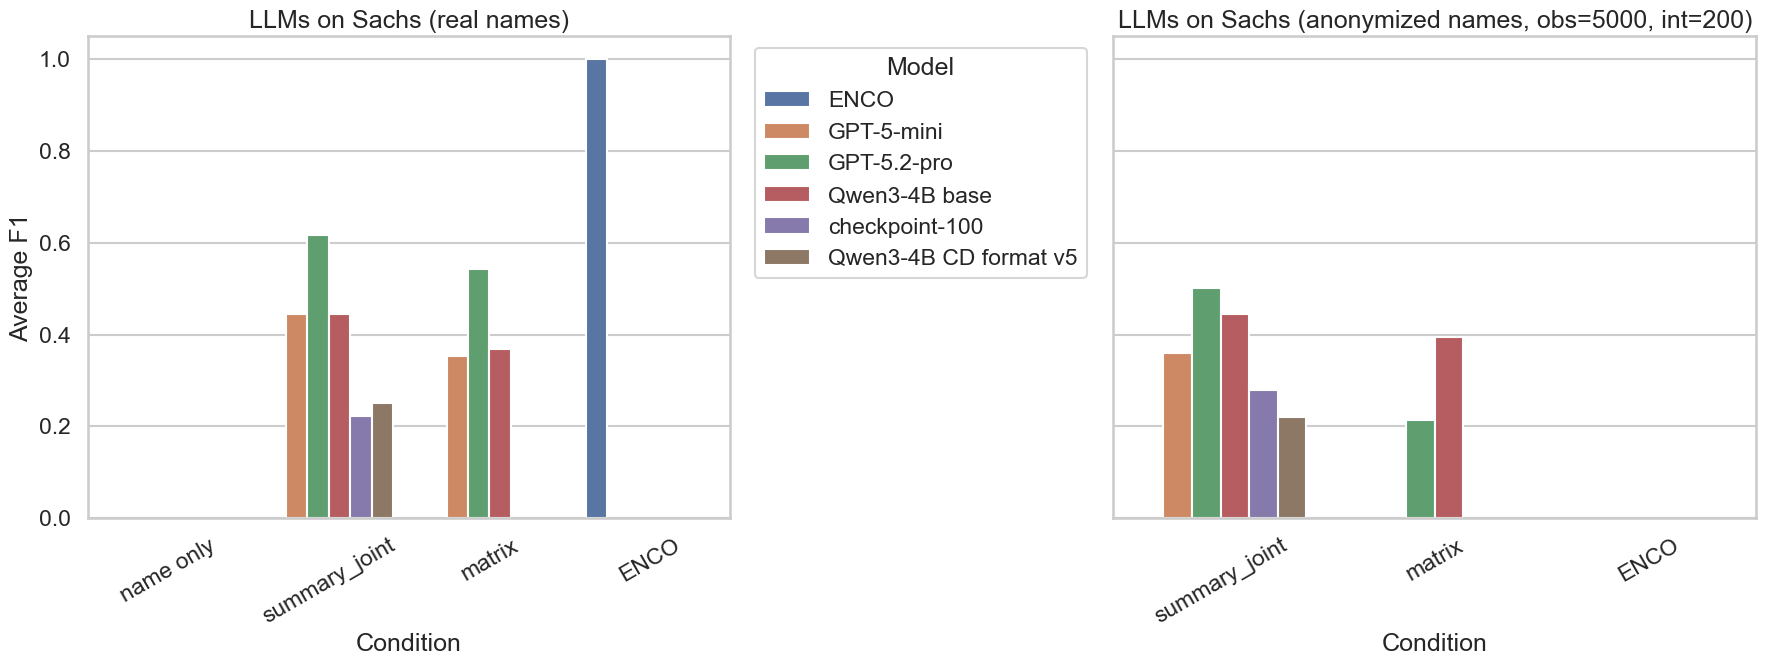

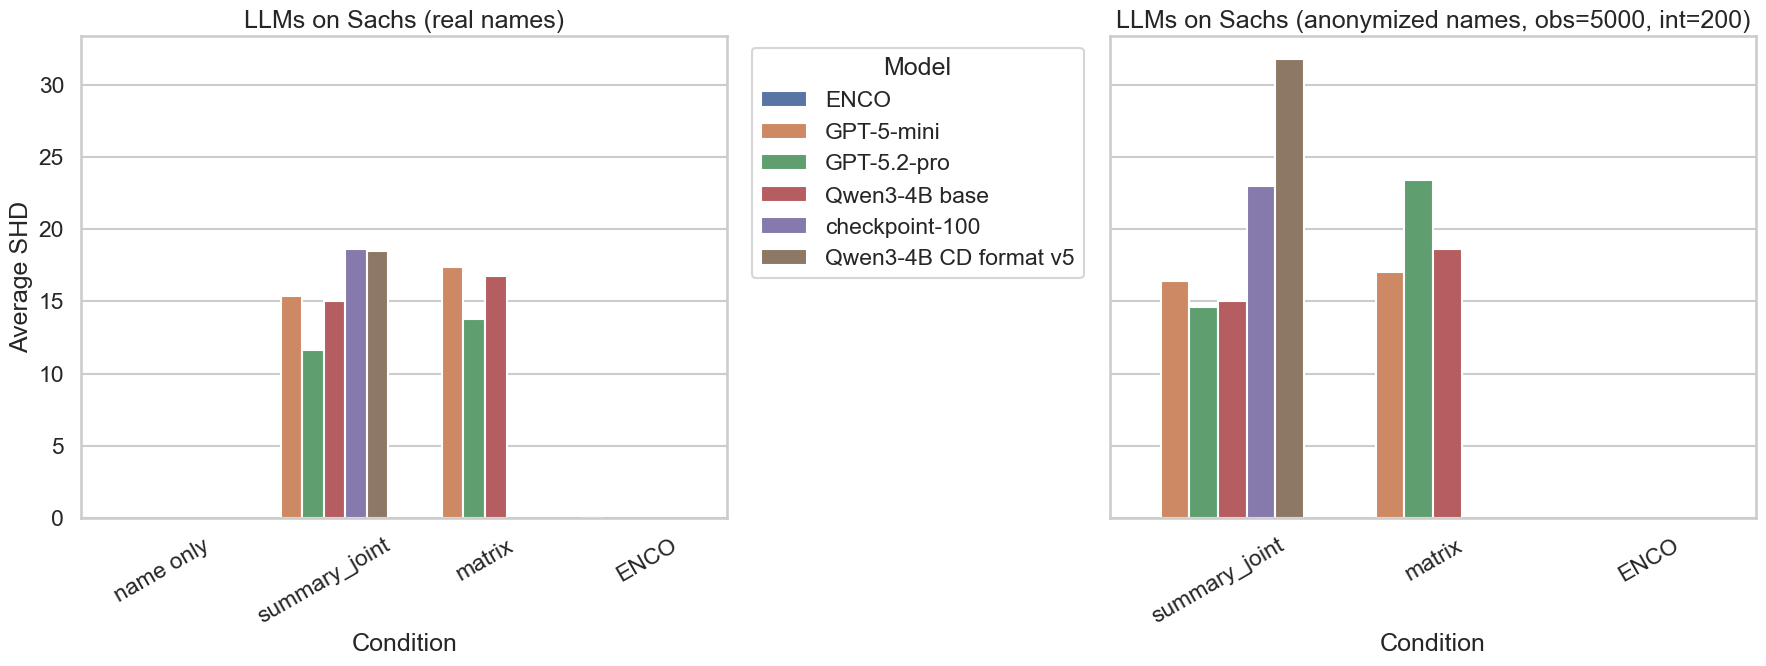

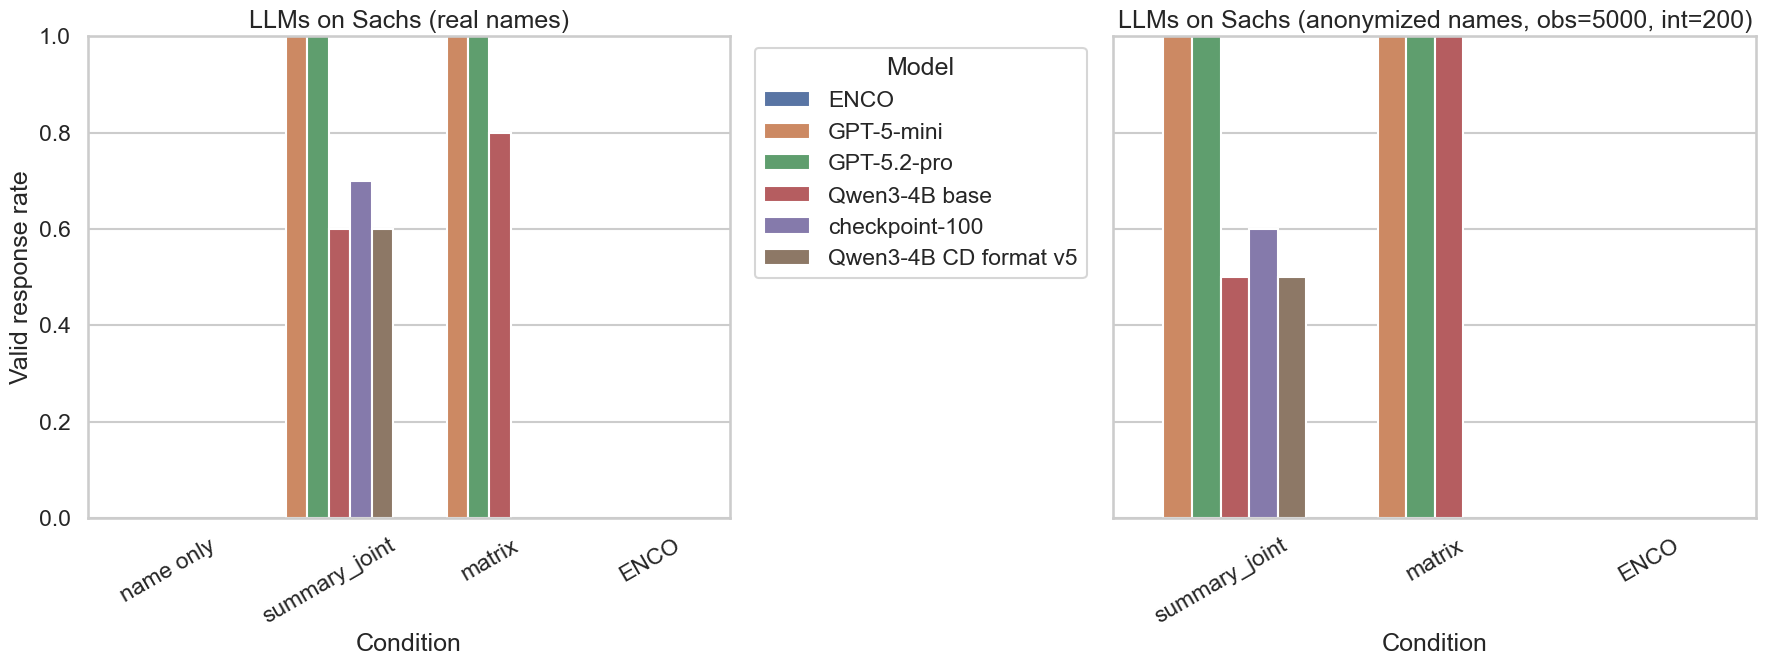

In [115]:
# Build an explicit plot table so missing/NaN values are transparent.
plot_cols = ["display_model", "setting", "avg_f1", "avg_shd", "valid_rows", "num_rows"]
plot_real_plot = plot_real[plot_cols].copy()
plot_anon_plot = plot_anon[plot_cols].copy()

for df in [plot_real_plot, plot_anon_plot]:
    df["avg_f1"] = pd.to_numeric(df["avg_f1"], errors="coerce")
    df["avg_shd"] = pd.to_numeric(df["avg_shd"], errors="coerce")
    df["valid_rows"] = pd.to_numeric(df["valid_rows"], errors="coerce")
    df["num_rows"] = pd.to_numeric(df["num_rows"], errors="coerce")
    df["valid_rate"] = (df["valid_rows"] / df["num_rows"]).where(df["num_rows"] > 0)

model_order = list(pretty_model.values())
real_setting_order = ["name only", "summary_joint", "matrix", "ENCO"]
anon_setting_order = ["summary_joint", "matrix", "ENCO"]

plot_real_plot["display_model"] = pd.Categorical(
    plot_real_plot["display_model"], categories=model_order, ordered=True
)
plot_anon_plot["display_model"] = pd.Categorical(
    plot_anon_plot["display_model"], categories=model_order, ordered=True
)
plot_real_plot["setting"] = pd.Categorical(
    plot_real_plot["setting"], categories=real_setting_order, ordered=True
)
plot_anon_plot["setting"] = pd.Categorical(
    plot_anon_plot["setting"], categories=anon_setting_order, ordered=True
)

# Collapse duplicates deterministically and keep NaN awareness.
plot_real_plot = (
    plot_real_plot.groupby(["display_model", "setting"], observed=True)
    .agg(avg_f1=("avg_f1", "mean"), avg_shd=("avg_shd", "mean"), valid_rate=("valid_rate", "mean"))
    .reset_index()
)
plot_anon_plot = (
    plot_anon_plot.groupby(["display_model", "setting"], observed=True)
    .agg(avg_f1=("avg_f1", "mean"), avg_shd=("avg_shd", "mean"), valid_rate=("valid_rate", "mean"))
    .reset_index()
)

coverage = pd.concat(
    [
        plot_real_plot.assign(panel="real"),
        plot_anon_plot.assign(panel="anonymized"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.barplot(
    data=plot_real_plot,
    x="setting",
    y="avg_f1",
    hue="display_model",
    order=real_setting_order,
    hue_order=model_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("LLMs on Sachs (real names)")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Average F1")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=plot_anon_plot,
    x="setting",
    y="avg_f1",
    hue="display_model",
    order=anon_setting_order,
    hue_order=model_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("LLMs on Sachs (anonymized names, obs=5000, int=200)")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Average F1")
axes[1].tick_params(axis="x", rotation=30)

if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()
axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.barplot(
    data=plot_real_plot,
    x="setting",
    y="avg_shd",
    hue="display_model",
    order=real_setting_order,
    hue_order=model_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("LLMs on Sachs (real names)")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Average SHD")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=plot_anon_plot,
    x="setting",
    y="avg_shd",
    hue="display_model",
    order=anon_setting_order,
    hue_order=model_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("LLMs on Sachs (anonymized names, obs=5000, int=200)")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Average SHD")
axes[1].tick_params(axis="x", rotation=30)

if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()
axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.barplot(
    data=plot_real_plot,
    x="setting",
    y="valid_rate",
    hue="display_model",
    order=real_setting_order,
    hue_order=model_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("LLMs on Sachs (real names)")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Valid response rate")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=plot_anon_plot,
    x="setting",
    y="valid_rate",
    hue="display_model",
    order=anon_setting_order,
    hue_order=model_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("LLMs on Sachs (anonymized names, obs=5000, int=200)")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Valid response rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30)

if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()
axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

## Qwen / GRPO comparison

This section is separate from the main benchmark cohort. It compares the pretrained Qwen model
against the SFT / GRPO variants on the Sachs settings they actually share.

By default, it uses the strongest shared slice we currently have in this folder:
- `names_only` with `p5`, and
- `thinktags` runs at `obs=0`, `int=200` for `summary_joint` and `matrix`.


In [11]:
qwen_grpo_models = [
    'Qwen3-4B-Thinking-2507',
    'checkpoint-4',
    'sft',
    'grpo_sachs_mix_onthefly_mp2',
    'grpo_sft_8192',
    'grpo_sft_8192_cd_focus',
    'grpo_sft_8192_from4096',
    'stage_3_obs100_int0_bootstrap',
    'stage_3_obs100_int0_graph_scaled',
    'stage_3_obs100_int0_retuned',
    "grpo_v2_cancer_eq"
]

cand = raw_summary[raw_summary['model'].isin(qwen_grpo_models)].copy()
cand['source_file'] = cand['response_csv'].map(lambda x: Path(x).name)

names_only = cand[cand['source_file'].str.contains(r'^responses_names_only_p5_', regex=True, na=False)].copy()
names_only['comparison_setting'] = 'names_only'

structured = cand[
    (cand['obs_n'].fillna(-1) == 5000)
    & (cand['int_n'].fillna(-1) == 200)
    & (cand['prompt_style'].isin(['summary_joint', 'matrix']))
    & (cand['source_file'].str.contains('thinktags', na=False))
].copy()
structured['comparison_setting'] = (
    structured['prompt_style'].astype(str)
    + ' / ' +
    structured['anonymize'].fillna(0).astype(int).map({1: 'anon', 0: 'real'})
)

grpo_compare = pd.concat([names_only, structured], ignore_index=True)

grpo_compare = grpo_compare[[
    'model', 'comparison_setting', 'prompt_style', 'obs_n', 'int_n', 'anonymize',
    'avg_f1', 'avg_shd', 'valid_rows', 'num_rows', 'source_file'
]].sort_values(['comparison_setting', 'avg_f1'], ascending=[True, False])

display(grpo_compare)


,model,comparison_setting,prompt_style,obs_n,int_n,anonymize,avg_f1,avg_shd,valid_rows,num_rows,source_file
19,stage_3_obs100_int0_bootstrap,matrix / anon,matrix,5000.0,200.0,1,0.444444,15.000000,2.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
14,checkpoint-4,matrix / anon,matrix,5000.0,200.0,1,0.429630,15.400000,5.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
15,grpo_sachs_mix_onthefly_mp2,matrix / anon,matrix,5000.0,200.0,1,0.425943,16.200000,5.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
13,Qwen3-4B-Thinking-2507,matrix / anon,matrix,5000.0,200.0,1,0.395195,18.600000,5.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
20,stage_3_obs100_int0_graph_scaled,matrix / anon,matrix,5000.0,200.0,1,0.394302,16.600000,5.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
16,grpo_sft_8192,matrix / anon,matrix,5000.0,200.0,1,0.384615,16.500000,2.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
18,grpo_sft_8192_from4096,matrix / anon,matrix,5000.0,200.0,1,0.377803,21.000000,3.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
21,stage_3_obs100_int0_retuned,matrix / anon,matrix,5000.0,200.0,1,0.345679,17.666667,3.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
17,grpo_sft_8192_cd_focus,matrix / anon,matrix,5000.0,200.0,1,0.305556,17.500000,2.0,5,responses_obs5000_int200_shuf1_p5_anon_thinkta...
37,grpo_sachs_mix_onthefly_mp2,matrix / real,matrix,5000.0,200.0,0,0.454023,16.600000,5.0,5,responses_obs5000_int200_shuf1_p5_thinktags_ma...


In [12]:
main_table.to_csv(TABLE_DIR / 'sachs_main_table_avg.csv', index=False)
repr_table.to_csv(TABLE_DIR / 'sachs_representation_table_avg.csv')
semantic_audit.to_csv(TABLE_DIR / 'sachs_semantic_audit_avg.csv', index=False)
grpo_compare.to_csv(TABLE_DIR / 'sachs_qwen_grpo_comparison.csv', index=False)

print('Saved paper tables to:', TABLE_DIR)
print('Saved figures to:', FIG_DIR)


Saved paper tables to: /Users/yuenc2/Desktop/ENCO/experiments/responses/sachs/paper_tables
Saved figures to: /Users/yuenc2/Desktop/ENCO/experiments/responses/sachs/paper_figures
